# 04 — Точечная сила: ε-свип к точному решению

Point = регуляризованный patch (NOTES §18: δ вне H¹ расщепления, КТН под δ расходится). Case: `cases/ci/circle_point.toml`.

eps=0.2: w_max=4.29768e-04, rel=1.027e-01
eps=0.1: w_max=4.55642e-04, rel=4.864e-02
eps=0.05: w_max=4.63742e-04, rel=3.173e-02


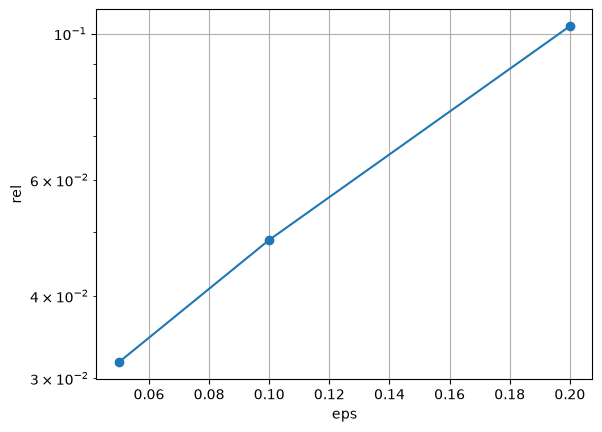

In [1]:
import dataclasses

import matplotlib.pyplot as plt

from plate_solver import analytic
from plate_solver.dispatch import solve
from plate_solver.problem import Problem

problem = Problem.from_toml("../cases/ci/circle_point.toml")
w_exact = analytic.circle_point_clamped_wmax(1.0, 1.0, problem.to_config().D)
eps_list, rels = [0.2, 0.1, 0.05], []
for eps in eps_list:
    prob = dataclasses.replace(problem, load=dataclasses.replace(problem.load, eps=eps))
    res = solve(prob)
    rels.append(abs(res.w_max - w_exact) / w_exact)
    print(f"eps={eps}: w_max={res.w_max:.5e}, rel={rels[-1]:.3e}")
plt.semilogy(eps_list, rels, "o-")
plt.xlabel("eps")
plt.ylabel("rel")
plt.grid(True)
# Монотонности по eps НЕТ и не должно быть: базисная ошибка полиномов на
# w ~ r²·ln r больше ошибки регуляризации (PROGRESS.md, NOTES §18).

## Квартет (D3): 3D-прогиб · карта σ · контактный планшет · сходимость


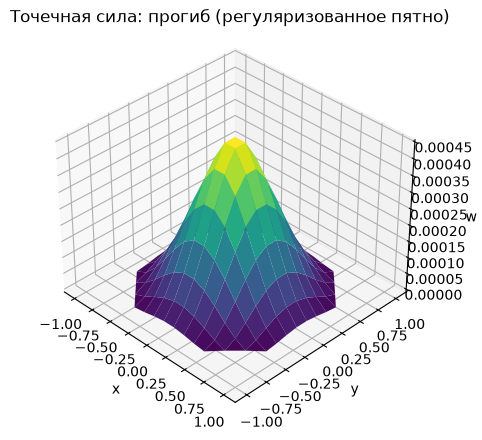

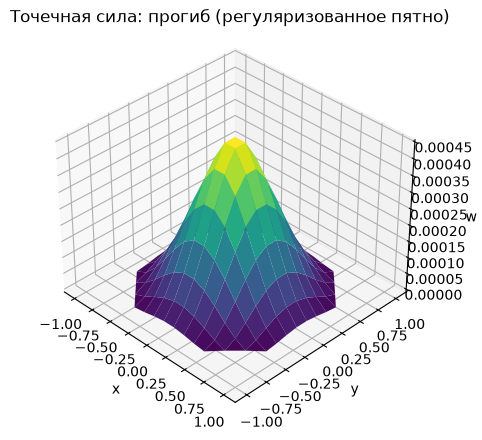

In [2]:
from plate_solver import viz

viz.surface3d(res.Xg, res.Yg, res.w_grid, elev=35, azim=-45,
              title="Точечная сила: прогиб (регуляризованное пятно)")